# Relatório Técnico: Pipeline MLOps para Previsão de Geração Eólica

**Autor:** Wanderson Ferreira

</div>
<left><img src="https://ne9.com.br/wp-content/uploads/2024/08/Parque-Eolico-Morro-de-Cruzeiro-da-Statkraft-Brasil-Foto-Divulgacao.webp"width="1000", height="680"/> <left> </div>
<p><left>(Parque Eólico Morro de Cruzeiro da da Statkraft Brasil, localizado em Brotas de Macaúbas, na Bahia. Foto Divulgação)</left></p>

Este notebook documenta a evolução de um experimento de previsão de geração eólica para uma arquitetura MLOps completa, com ingestão de dados, contratos, engenharia de features, treinamento temporal, rastreamento no MLflow, serving em Kubernetes, monitoramento de drift, explicabilidade e Continuous Training.

---


## Status Atual do Sistema MLOps

O projeto está operacional em ambiente local reprodutível com **Python 3.14**, **Poetry**, **Prefect 3**, **MLflow**, **RustFS**, **PostgreSQL**, **FastAPI**, **Streamlit**, **Helm** e **Kubernetes/KinD**.

O estado consolidado é:

- **Dados e contratos:** meteorologia via Open-Meteo, geração via ONS e capacidade instalada canônica via checkpoints ABEEólica/INFOVENTO, com validação por Pandera e payloads HTTP por Pydantic.
- **Feature engineering:** contrato único definido por `ModelFeatureSchema`, com 9 features canônicas e rolling de vento causal.
- **Object Storage:** RustFS compatível com S3; datasets operacionais na camada Gold de `energy-lake` e artefatos do MLflow em `mlflow-artifacts`.
- **Modelagem:** `TemporalStackingRegressor` com arquitetura configurável de estimadores base; o Champion operacional permanece `LightGBM + XGBoost + Random Forest`, com meta-learner `LinearRegression(positive=True, fit_intercept=False)`.
- **Otimização:** Optuna com validação temporal; o orquestrador aceita otimização **opcional**, permitindo trainers que não dependem de busca de hiperparâmetros.
- **MLflow:** Tracking Server com PostgreSQL como backend store, RustFS como artifact store e Model Registry com alias `@champion`.
- **Serving:** FastAPI em Kubernetes com `/health`, `/model-info`, `/predict/batch` e `/reload-model`.
- **XAI:** artefatos SHAP vinculados ao `run_id` da mesma Run efetivamente servida.
- **Monitoring:** Evidently para Data Drift e cálculo independente de Performance Drift; o CT pode ser acionado por `Data Drift OR Performance Drift`.
- **Governança:** Challenger só substitui Champion após Quality Gate. A última execução real treinou o Challenger v12, que foi rejeitado; o Champion permaneceu na versão v10.
- **Validação:** suíte final com **122 testes aprovados**, além de Ruff e `git diff --check` limpos. Os 2 warnings observados no Tox vêm de dependências internas, sem falha da suíte.
- **Operação local:** `make status` fornece diagnóstico observacional e `make validate` funciona como gate operacional para Kubernetes, endpoints HTTP e modelo em produção.
- **CI/CD:** GitHub Actions executa testes e, após build verde, publica a imagem da FastAPI no GHCR. O rollout no Kubernetes local permanece **manual**, portanto o projeto não é descrito como GitOps completo.

### Contrato atual de features

```text
temperature_2m
wind_speed_100m
wind_direction_100m
wind_temp_ratio
hour_sin
hour_cos
month_sin
month_cos
wind_speed_roll_mean_3h
```

### Estado atual do Model Registry

```text
Model: ensemble_lgb_xgb_rf_bahia
Alias: @champion
Champion: v10
Run ID: d466ccb7fa294851a86a73b05d4e5735
OOT MAE: 829.59 MW
OOT nMAE: 7.04%
OOT R²: 0.8477
Features: 9
```

A compatibilidade com métricas históricas `*_YYYY` ainda é mantida para permitir governança entre gerações antigas e o contrato atual. Novas Runs utilizam exclusivamente os nomes canônicos.

### Estado após o experimento v0.2.0

O experimento de simplificação realizado em 2026-10-01 não alterou
automaticamente o modelo operacional.

O alias `@champion` permanece associado à v10 do Registered Model
`ensemble_lgb_xgb_rf_bahia`.

Os resultados da v0.2.0 foram produzidos sobre um novo snapshot
temporal congelado e são tratados como evidência experimental.
Eles não são comparados diretamente com as métricas históricas da
v10 para fins de promoção, pois os períodos OOT são diferentes.


## 1. Introdução ao Problema

A geração eólica varia com as condições meteorológicas e com a capacidade operacional disponível ao longo do tempo. Em um cenário de despacho Day-Ahead, a tarefa de Machine Learning não consiste apenas em ajustar um regressor, mas em manter um ciclo confiável entre **dados, modelo, software e operação**.

Este projeto desenvolve um sistema MLOps para previsão horária de geração eólica na Bahia. O pipeline integra dados meteorológicos da **Open-Meteo** e dados de geração do **ONS**, constrói features causais, estima um **fator de capacidade (`target_fc`)**, converte a previsão para MW usando a capacidade operacional e governa a evolução do modelo por meio de validação Out-of-Time, Model Registry, monitoramento e Continuous Training.

O objetivo técnico é que o mesmo contrato seja respeitado por todas as etapas:

```text
dados → features → otimização → treino → avaliação → registry
     → serving → monitoring → continuous training
```

Essa abordagem reduz o risco de divergências silenciosas entre o que foi treinado, o que está sendo servido e o que é monitorado em produção.


## 2. Dicionário de Dados

A arquitetura consolida variáveis de fontes distintas em granularidade **horária**.

### 2.1. Variáveis meteorológicas — Open-Meteo

No produto operacional, a previsão Day-Ahead é obtida para **Morro do Chapéu - BA**.

| Campo | Tipo | Papel |
|---|---|---|
| `date` | timestamp | referência temporal |
| `temperature_2m` | float | temperatura do ar a 2 m |
| `wind_speed_100m` | float | velocidade do vento a 100 m |
| `wind_direction_100m` | float | direção do vento a 100 m |

### 2.2. Variáveis de geração — ONS

| Campo | Tipo | Papel |
|---|---|---|
| `date` | timestamp | alinhamento temporal com os dados meteorológicos |
| `wind_generation_mw` | float | geração eólica observada em MW |

### 2.3. Capacidade instalada — ABEEólica / INFOVENTO

| Campo | Tipo | Papel |
|---|---|---|
| `capacidade_mw` | float | capacidade instalada canônica utilizada para normalização do target e reconversão da previsão para MW |

A capacidade é representada por checkpoints históricos publicados pelo
ABEEólica/INFOVENTO e aplicada de forma causal: em cada timestamp é
utilizado somente o checkpoint mais recente já disponível.

Não são utilizados interpolação linear nem backward fill.

Os dados da ANEEL são mantidos como fonte diagnóstica independente
para reconciliação de eventos de entrada em operação, mas não são
utilizados para reconstruir a série canônica `capacidade_mw`.

### 2.4. Target de modelagem

O target é o fator de capacidade:

$$
target\_fc =
clip\left(
\frac{wind\_generation\_mw}{capacidade\_mw},
0, 1
\right)
$$

Durante a inferência, o modelo prevê `predicted_fc` e a potência é reconstruída por:

$$
predicted\_mw = predicted\_fc \times capacidade\_mw
$$

Isso mantém a aprendizagem em escala relativa, enquanto as métricas operacionais continuam sendo calculadas em MW e em percentual normalizado.


## 3. Design da Solução e Arquitetura

O projeto usa **src layout**, separação entre domínio e orquestração e uma estrutura de testes que espelha as principais camadas de produção. O repositório não depende de um template Cookiecutter para ser organizado; a arquitetura foi consolidada conforme as responsabilidades reais surgiram.

Arquivos locais de runtime — logs, caches, bancos SQLite auxiliares, secrets, evidências E2E e datasets Parquet — são deliberadamente mantidos fora do Git.

```text
renewable-energy-mlops/
├── .github/
│   └── workflows/
│       └── ci_cd.yaml
├── helm/
│   ├── Chart.yaml
│   ├── values.yaml
│   └── templates/
│       ├── api.yaml
│       ├── mlflow.yaml
│       ├── postgres.yaml
│       └── rustfs.yaml
├── notebooks/
│   ├── extract_test.png
│   ├── renewable-energy-mlops.ipynb
│   ├── streamlit_day_ahead.png
│   └── streamlit_monitoring.png
├── src/
│   └── energy_mlops/
│       ├── app/
│       │   └── app.py
│       ├── data/
│       │   ├── build_features.py
│       │   ├── extract_energy.py
│       │   ├── extract_weather.py
│       │   ├── feature_utils.py
│       │   └── schema.py
│       ├── models/
│       │   ├── interfaces.py
│       │   ├── optimize_stacking_ensemble.py
│       │   ├── temporal_stacking.py
│       │   ├── train_examples.py
│       │   └── train_stacking_ensemble.py
│       ├── pipelines/
│       │   ├── backfill_flow.py
│       │   ├── data_ingestion_flow.py
│       │   ├── monitoring_flow.py
│       │   ├── training_flow.py
│       │   └── utils.py
│       ├── service/
│       │   ├── main.py
│       │   ├── schema.py
│       │   └── xai_artifacts.py
│       └── config.py
├── tests/
│   ├── data/
│   ├── models/
│   │   ├── test_optimize_stacking_ensemble.py
│   │   ├── test_temporal_stacking.py
│   │   ├── test_train_examples.py
│   │   └── test_train_stacking_ensemble.py
│   ├── pipelines/
│   ├── service/
│   ├── conftest.py
│   └── test_config.py
├── Dockerfile
├── Makefile
├── pyproject.toml
├── poetry.lock
├── tox.ini
└── README.md
```

### Arquitetura lógica

```text
Open-Meteo ───────────┐
ONS ──────────────────┼──> Prefect Data Flows ──> Pandera ──> Feature Engineering
ABEEólica/INFOVENTO ──┘                                  │
                                                   ▼
                                             RustFS / Gold
                                                   │
                         ┌─────────────────────────┴─────────────────────────┐
                         │                                                   │
                         ▼                                                   ▼
                Monitoring Flow                                      Training Flow
                Evidently + nMAE                                optimizer opcional
                         │                                                   │
             drift? ────┴──── yes                                           ▼
                         │                                      TemporalStackingRegressor
                         └──────────────────────────────────────> OOT Evaluation
                                                                     │
                                                                     ▼
                                                               Quality Gate
                                                                     │
                                                                     ▼
                                                            MLflow Model Registry
                                                               alias @champion
                                                                     │
                                                                     ▼
                                            FastAPI <── POST /reload-model
                                               │
                                  ┌────────────┴────────────┐
                                  ▼                         ▼
                           /predict/batch              /model-info
                                  │                         │
                                  └────────────┬────────────┘
                                               ▼
                                            Streamlit
                                     Day-Ahead + XAI + Drift
```

O MLflow usa PostgreSQL como backend store e RustFS como artifact store. A FastAPI é empacotada em Docker, publicada no GHCR pelo CI e executada em Kubernetes/KinD por manifests Helm. O rollout local permanece uma ação operacional explícita.


## P1. Pipeline de Ingestão e Backfill

A camada de ingestão mantém os extratores de domínio separados da orquestração. `extract_weather.py` e `extract_energy.py` concentram a lógica de acesso às fontes; os flows Prefect apenas coordenam execução, retries, transformação e persistência.

Os contratos Pandera funcionam como barreira de qualidade antes que os dados avancem para feature engineering, treinamento ou monitoramento.

### P1.1. Validação inicial da ingestão

A primeira validação mensal verificou o alinhamento horário entre clima e geração. Para janeiro, o pipeline produziu os 744 registros esperados (`31 × 24`), sem lacunas no join temporal.

<img src="extract_test.png" width="1100">


### P1.2. Revisão de proveniência e causalidade — v0.2.0

Antes do experimento de simplificação do ensemble, a camada de dados
foi revisada para fortalecer proveniência e consistência temporal.

Na geração do ONS, valores ausentes no nível de usina não são
convertidos em zero. Se qualquer registro necessário estiver ausente
em determinada hora, a hora é considerada incompleta e excluída antes
da agregação estadual.

A capacidade instalada passou a utilizar checkpoints históricos do
ABEEólica/INFOVENTO como referência canônica. A associação temporal é
causal e não utiliza informações futuras para reconstruir observações
passadas.

O Gold consolidado utilizado na v0.2.0 também passou por auditoria
automática de invariantes estruturais, físicos e temporais.

O snapshot experimental congelado contém:

```text
rows: 22,145
range: 2024-03-21 00:00:00 → 2026-10-01 02:00:00
missing timestamps: 34
gaps: 2
features: 9
```

As 34 horas ausentes pertencem a dois gaps históricos conhecidos. O período OOT de setembro/2026 contém 720 observações, sem timestamps ausentes e sem gaps.

Esse snapshot é o ponto inicial confiável para novos experimentos que dependam de `capacidade_mw`; dados anteriores permanecem úteis como evidência histórica de EDA, mas não fazem parte do contrato canônico de treinamento da v0.2.0.

### P1.3. EDA histórica

O backfill histórico foi usado para consolidar um snapshot de análise exploratória de 2023–2025. As células seguintes preservam os outputs dessa execução como evidência analítica do desenvolvimento inicial.

> **Nota de reprodutibilidade:** o snapshot bruto utilizado nessa EDA não é mais versionado no Git. Datasets operacionais e Parquets locais são mantidos fora do repositório; o pipeline atual utiliza a camada Gold no RustFS como fonte operacional. Portanto, a parte de EDA abaixo deve ser entendida como registro histórico do experimento, não como fonte do Continuous Training atual.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller

# Carregar dataset completo
df = pd.read_parquet("../data/dataset_historico_2023_2025.parquet")

#  Estatísticas Descritivas
print("--- Visão Geral do Dataset ---")
print(f"Período: {df['date'].min()} até {df['date'].max()}")
print(f"Total de Horas Observadas: {len(df):,}")
print(f"Valores Ausentes:\n{df.isnull().sum()}\n")

print("--- Estatísticas Numéricas ---")
print(df[["wind_speed_100m", "temperature_2m", "wind_generation_mw"]].describe().T)

# Matriz de Correlação Linear
corr = df[["wind_speed_100m", "wind_direction_100m", "temperature_2m", "wind_generation_mw"]].corr()
print("\n--- Correlação com a Geração (Target) ---")
print(corr["wind_generation_mw"].sort_values(ascending=False))

#  Perfis Médios por Hora do Dia
df['hour'] = df['date'].dt.hour
hourly_profile = df.groupby('hour')[['wind_speed_100m', 'wind_generation_mw']].mean()
print("\n--- Horário de Pico de Vento x Geração Média ---")
print(hourly_profile.sort_values(by="wind_generation_mw", ascending=False).head(24))

--- Visão Geral do Dataset ---
Período: 2023-01-01 03:00:00 até 2026-01-01 02:00:00
Total de Horas Observadas: 26,304
Valores Ausentes:
date                   0
wind_speed_100m        0
wind_direction_100m    0
temperature_2m         0
wind_generation_mw     0
dtype: int64

--- Estatísticas Numéricas ---
                      count         mean          std     min          25%  \
wind_speed_100m     26304.0    23.696213     7.167144   0.360    19.160703   
temperature_2m      26304.0    20.475441     3.853555  12.100    17.600000   
wind_generation_mw  26304.0  4096.434799  2324.321783  53.819  2133.110000   

                            50%          75%           max  
wind_speed_100m       23.833182    28.460497     52.488441  
temperature_2m        19.799999    23.100000     33.750000  
wind_generation_mw  4151.848500  5713.510250  10373.281000  

--- Correlação com a Geração (Target) ---
wind_generation_mw     1.000000
wind_speed_100m        0.680618
wind_direction_100m   -0.00443

### P1.4. Resultados Estatísticos do Snapshot Histórico

A execução histórica consolidou **26.304 registros horários**, cobrindo aproximadamente três anos de observações contínuas.

Os resultados preservados nas células anteriores/seguintes mostram:

- ausência de valores faltantes no snapshot analisado;
- relação positiva relevante entre `wind_speed_100m` e geração;
- diferença sazonal estatisticamente significativa entre períodos do ano;
- diferenças no perfil de geração ao longo do ciclo diário.

Essas observações orientaram a criação de features temporais e de interação, mas **não determinam sozinhas** quais variáveis permanecem no contrato final. A seleção atual é governada pelo `ModelFeatureSchema`, por validações temporais e por evidências posteriores de importância/ablação.


In [20]:
# --- Engenharia de Features Temporais para Sazonalidade ---
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["quarter"] = df["date"].dt.quarter
df["year_quarter"] = df["year"].astype(str) + "-Q" + df["quarter"].astype(str)

# Flag da "Safra dos Ventos" no Nordeste (Geralmente Agosto a Novembro)
df["safra_ventos"] = df["month"].isin([8, 9, 10, 11]).map({True: "Safra (Ago-Nov)", False: "Fora de Safra"})

# --- Agregações por Trimestre e Ano ---
pivot_generation = df.pivot_table(
    index="year", 
    columns="quarter", 
    values="wind_generation_mw", 
    aggfunc=["mean", "std"]
)
print("=== Geração Média (MW) por Ano e Trimestre ===")
print(pivot_generation.round(2))

=== Geração Média (MW) por Ano e Trimestre ===
            mean                                 std                    \
quarter        1        2        3        4        1        2        3   
year                                                                     
2023     3089.41  3521.81  3985.05  3388.39  1640.86  1680.42  1596.08   
2024     2457.38  4285.74  5258.58  4223.25  1810.16  1795.78  1831.16   
2025     3293.04  5108.14  5982.23  4511.11  2307.27  2377.21  2699.29   
2026     5091.75      NaN      NaN      NaN   465.46      NaN      NaN   

                  
quarter        4  
year              
2023     1835.37  
2024     2355.81  
2025     2891.52  
2026         NaN  


In [21]:
# --- Testes Estatísticos ---
print("\n" + "="*50)
print("=== RESULTADOS DOS TESTES ESTATÍSTICOS ===")

# A. Teste de Estacionariedade (ADF) na Geração
adf_result = adfuller(df["wind_generation_mw"].dropna(), result_object=True)
print(f"\n1. Teste de Estacionariedade (ADF) - Geração (MW):")
print(f"   - Estatística ADF: {adf_result[0]:.4f}")
print(f"   - p-valor: {adf_result[1]:.4e}")
print(f"   - Resultado: {'Série Estacionária (Rejeita H0)' if adf_result[1] < 0.05 else 'Não Estacionária'}")

# B. Teste Kruskal-Wallis (Sazonalidade entre Trimestres)
q1 = df[df["quarter"] == 1]["wind_generation_mw"]
q2 = df[df["quarter"] == 2]["wind_generation_mw"]
q3 = df[df["quarter"] == 3]["wind_generation_mw"]
q4 = df[df["quarter"] == 4]["wind_generation_mw"]
kw_stat, kw_p = stats.kruskal(q1, q2, q3, q4)
print(f"\n2. Teste Kruskal-Wallis (Diferença entre Trimestres Q1-Q4):")
print(f"   - Estatística H: {kw_stat:.2f}")
print(f"   - p-valor: {kw_p:.4e}")
print(f"   - Resultado: {'Diferença Sazonal Estatisticamente Significativa' if kw_p < 0.05 else 'Sem Diferença Significativa'}")

# C. Correlação de Spearman vs Pearson
pearson_corr = df["wind_speed_100m"].corr(df["wind_generation_mw"], method="pearson")
spearman_corr = df["wind_speed_100m"].corr(df["wind_generation_mw"], method="spearman")
print(f"\n3. Comparação de Correlações (Vento x Geração):")
print(f"   - Pearson (Linear): {pearson_corr:.4f}")
print(f"   - Spearman (Monótona/Não-linear): {spearman_corr:.4f}")


=== RESULTADOS DOS TESTES ESTATÍSTICOS ===

1. Teste de Estacionariedade (ADF) - Geração (MW):
   - Estatística ADF: -10.6483
   - p-valor: 4.7338e-19
   - Resultado: Série Estacionária (Rejeita H0)

2. Teste Kruskal-Wallis (Diferença entre Trimestres Q1-Q4):
   - Estatística H: 2800.11
   - p-valor: 0.0000e+00
   - Resultado: Diferença Sazonal Estatisticamente Significativa

3. Comparação de Correlações (Vento x Geração):
   - Pearson (Linear): 0.6806
   - Spearman (Monótona/Não-linear): 0.6937


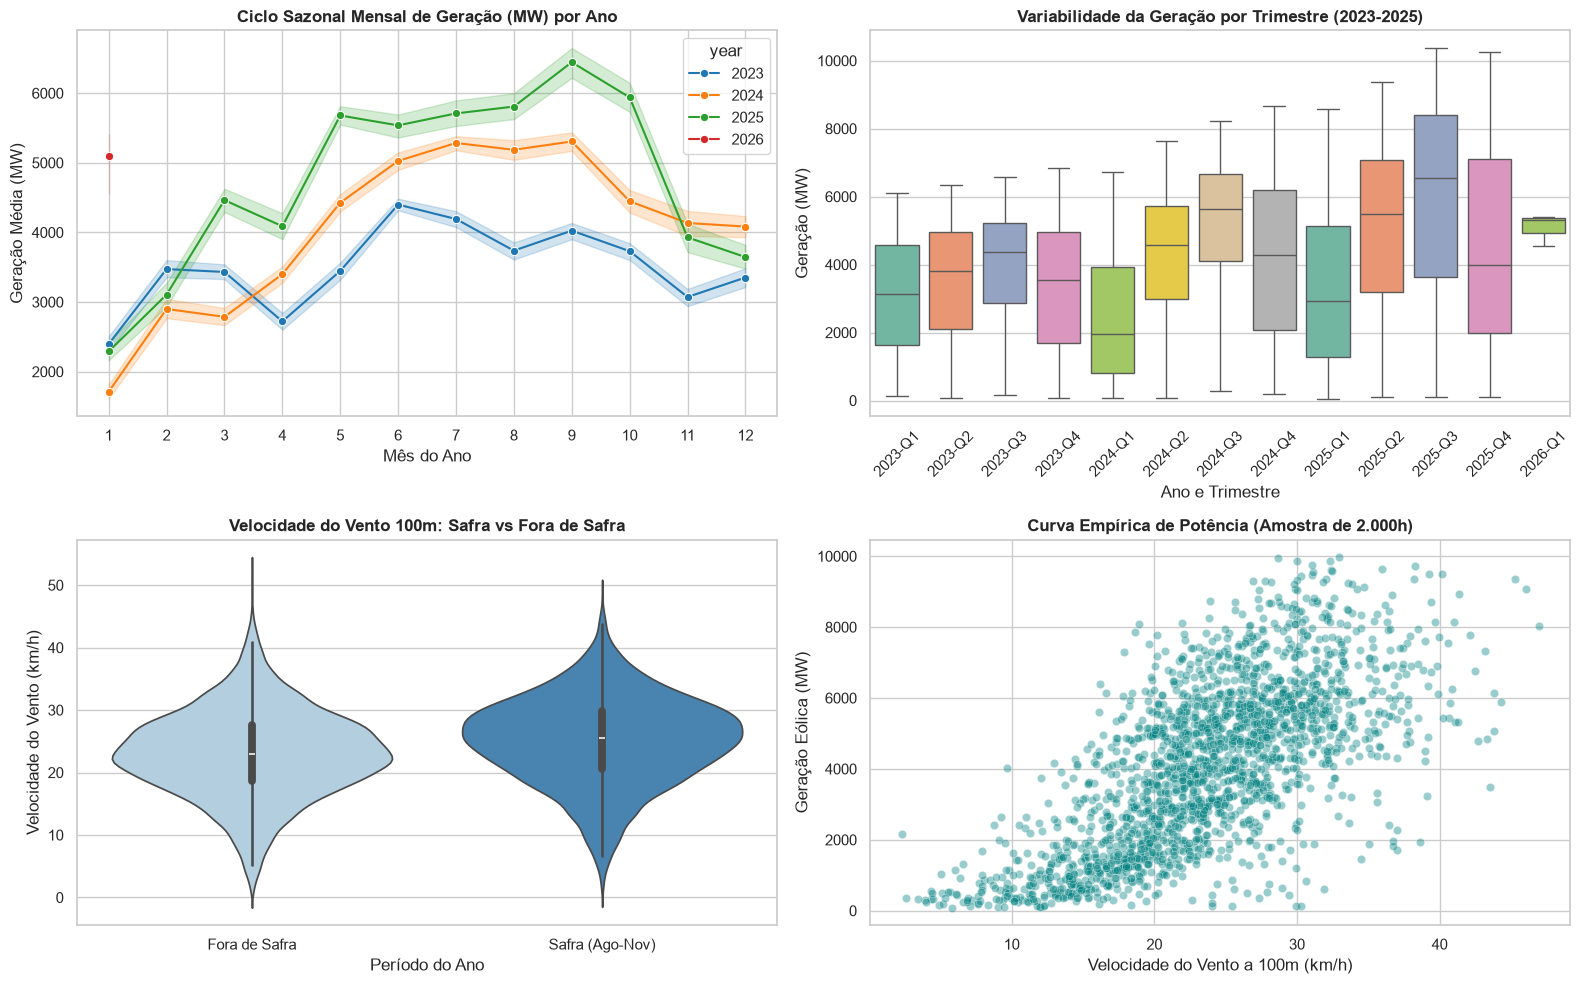

In [23]:
# ---  Visualizações Gráficas ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Gráfico 1: Evolução Mensal da Geração (2023-2025) - Evidenciando a Safra
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
sns.lineplot(data=df, x="month", y="wind_generation_mw", hue="year", palette="tab10", marker="o", ax=axes[0, 0])
axes[0, 0].set_title("Ciclo Sazonal Mensal de Geração (MW) por Ano", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Mês do Ano")
axes[0, 0].set_ylabel("Geração Média (MW)")
axes[0, 0].set_xticks(range(1, 13))

# Gráfico 2: Distribuição por Trimestre (Boxplot) 
sns.boxplot(data=df, x="year_quarter", y="wind_generation_mw", hue="year_quarter", palette="Set2", legend=False, ax=axes[0, 1])
axes[0, 1].set_title("Variabilidade da Geração por Trimestre (2023-2025)", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Ano e Trimestre")
axes[0, 1].set_ylabel("Geração (MW)")
axes[0, 1].tick_params(axis='x', rotation=45)

# Gráfico 3: Safra dos Ventos vs Fora de Safra 
sns.violinplot(data=df, x="safra_ventos", y="wind_speed_100m", hue="safra_ventos", palette="Blues", legend=False, ax=axes[1, 0])
axes[1, 0].set_title("Velocidade do Vento 100m: Safra vs Fora de Safra", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Período do Ano")
axes[1, 0].set_ylabel("Velocidade do Vento (km/h)")

# Gráfico 4: Curva Empírica de Potência (Vento vs Geração)
sns.scatterplot(data=df.sample(2000, random_state=42), x="wind_speed_100m", y="wind_generation_mw", alpha=0.4, color="teal", ax=axes[1, 1])
axes[1, 1].set_title("Curva Empírica de Potência (Amostra de 2.000h)", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Velocidade do Vento a 100m (km/h)")
axes[1, 1].set_ylabel("Geração Eólica (MW)")

plt.tight_layout()
plt.show()


### P1.5. Perfil Diurno Observado na EDA Histórica

O agrupamento horário do snapshot histórico mostrou geração média elevada durante a madrugada em UTC, acompanhando o comportamento do vento observado no período analisado.

Esses resultados foram úteis para justificar features temporais cíclicas (`hour_sin` e `hour_cos`). Eles não são tratados como uma regra física fixa nem como garantia de comportamento futuro; o sistema operacional usa dados meteorológicos atualizados e monitora drift para detectar mudanças nas distribuições.


## P2. Engenharia de Features e Contrato Canônico

A engenharia de features é implementada em `src/energy_mlops/data/build_features.py`, enquanto a seleção oficial é centralizada em `ModelFeatureSchema` e `feature_utils.py`.

O contrato atual contém **9 features**, em ordem determinística:

```text
temperature_2m
wind_speed_100m
wind_direction_100m
wind_temp_ratio
hour_sin
hour_cos
month_sin
month_cos
wind_speed_roll_mean_3h
```

### Decisões principais

**Interação vento–temperatura.** `wind_temp_ratio` preserva uma interação simples entre condições térmicas e vento que apresentou utilidade preditiva nas análises posteriores.

**Sazonalidade cíclica.** Hora e mês são representados por seno e cosseno, evitando que o modelo trate a fronteira 23h→0h ou dezembro→janeiro como uma distância artificialmente grande.

**Rolling causal e gap-safe.** `wind_speed_roll_mean_3h` utiliza uma
janela cronológica de três horas, e não simplesmente as três linhas
anteriores do DataFrame. A feature usa somente informação disponível
até cada instante e não atravessa artificialmente grandes lacunas
temporais.

**Ablação.** Features experimentais como `wind_speed_cubed` e `wind_speed_lag_1h` foram removidas do contrato final após avaliação de redundância/importância. Elas fazem parte da história experimental, mas não entram mais no modelo atual.

### Target normalizado

$$
target\_fc
= clip\left(
\frac{wind\_generation\_mw}{capacidade\_mw},
0,
1
\right)
$$

O modelo aprende o fator de capacidade; as métricas operacionais são obtidas depois da reconversão para MW:

$$
predicted\_mw
= predicted\_fc
\times
capacidade\_mw
$$

Essa separação evita confundir erro em fator de capacidade com erro em MW.

### Um único contrato para todo o lifecycle

```text
Optimization ─┐
Training ─────┼──> ModelFeatureSchema
Serving ──────┤
Monitoring ───┘
```

A centralização impede que uma etapa descubra features por heurísticas próprias e reduz o risco de divergência entre treinamento, inferência e monitoramento.


## P3. Data Lake S3-Compatible: RustFS

A camada de armazenamento foi desenhada sobre a API **S3**, desacoplando os pipelines da implementação concreta de Object Storage.

A primeira versão utilizava MinIO. A infraestrutura atual usa **RustFS**, mantendo o mesmo contrato S3 para leitura e escrita dos objetos. Por isso, a migração exigiu principalmente mudanças de infraestrutura e configuração, sem reescrever a lógica central dos pipelines.

### Organização lógica

```text
RustFS
├── energy-lake/
│   ├── gold/*.parquet
│   └── monitoring/drift_report.html
└── mlflow-artifacts/
    ├── model/
    ├── model_summary.json
    └── artefatos SHAP
```

O RustFS roda no cluster KinD com persistência via PVC. PostgreSQL possui seu próprio armazenamento persistente e atua como backend store do MLflow.

As credenciais locais ficam em `helm/values_secrets.yaml`, arquivo ignorado pelo Git. O repositório versiona apenas a configuração reproduzível que não contém segredos.

Datasets Parquet de trabalho também não são mais versionados no Git. O Data Lake é a fonte operacional, enquanto `data/` funciona apenas como workspace/fallback local quando necessário.


---
## P4. Modelagem, Otimização Temporal e Governança com MLflow

A camada de modelagem evoluiu de baselines e ensembles convencionais para uma arquitetura especificamente projetada para séries temporais.

### P4.1. Temporal Stacking

O modelo atual combina:

```text
LightGBM ───┐
XGBoost ────┼──> OOF causais ──> LinearRegression
RandomForest┘                   positive=True
                                  fit_intercept=False
```

`TemporalStackingRegressor` usa `TimeSeriesSplit` para produzir previsões Out-of-Fold sem treinar modelos base com observações futuras em relação ao bloco de validação.

O bloco inicial que não recebe OOF é excluído do ajuste do meta-learner. Depois disso, os modelos base são refitados sobre todo o conjunto de treino disponível.

### P4.2. Otimização com Optuna

A função objetivo usa a mesma arquitetura temporal do treinamento final. Há dois níveis temporais:

```text
Outer TimeSeriesSplit
    └── estima desempenho futuro do trial

Inner TimeSeriesSplit
    └── gera OOF causais para o meta-learner
```

A otimização retorna explicitamente:

```python
{
    "optimization_run_id": "...",
    "best_params": {...},
}
```

Esse resultado é propagado ao trainer e registrado como lineage no MLflow.

### P4.3. Optimizer agora é opcional no orquestrador

O `training_flow.py` deixou de assumir que todo algoritmo de treinamento precisa de Optuna.

```text
optimizer_name="stacking"
        ↓
Optuna → best_params → trainer

optimizer_name="none"
        ↓
pula otimização
        ↓
trainer recebe best_params=None
              optimization_run_id=None
```

`ModelTrainer` aceita os dois cenários. Cada implementação decide se a otimização é obrigatória. O `train_stacking_regressor`, por exemplo, falha rapidamente quando `best_params` ou `optimization_run_id` estão ausentes; já `train_examples.py` demonstra como um Ridge pode operar sem optimizer.

Essa separação torna o Prefect um **orquestrador agnóstico**, em vez de acoplá-lo a um único algoritmo.

### P4.4. Métricas canônicas

Novas Runs registram:

```text
oot_mae_mw
oot_nmae_pct
oot_mae_fc_pct
oot_r2_score
```

O ano não faz parte do nome da métrica. Temporalidade e janela de avaliação pertencem aos metadados/datasets da Run.

Uma camada de compatibilidade aceita uma única variante histórica `_<YYYY>` quando a métrica canônica está ausente. Essa compatibilidade existe para governança entre gerações antigas e poderá ser removida quando nenhum modelo operacional relevante depender dela.

### P4.5. MLflow e Model Registry

O MLflow registra:

- datasets de treino e OOT;
- parâmetros e hiperparâmetros;
- número de features;
- métricas de treino e OOT;
- pesos do meta-learner;
- `model_summary.json`;
- artefatos SHAP;
- tags do Quality Gate;
- vínculo entre Optimization Run e Training Run.

A identidade operacional atualmente consumida pelo serving permanece:

```text
ensemble_lgb_xgb_rf_bahia@champion
```

Cujo o alias operacional é:

```text
@champion
```

Durante os experimentos da v0.2.0, as arquiteturas candidatas passaram
a utilizar nomenclatura própria de Run e Registered Model:

```text
LGBM + XGB + RF → ensemble_lgb_xgb_rf_bahia
LGBM + RF       → ensemble_lgb_rf_bahia
LGBM + XGB      → ensemble_lgb_xgb_bahia
```

### P4.6. Execução real do último Challenger

Na execução real de Continuous Training validada neste projeto:

```text
Champion v10
MAE OOT   = 829.59 MW
nMAE OOT  = 7.04%
R² OOT    = 0.8477
Features  = 9

Challenger v12
MAE OOT   = 837.85 MW
nMAE OOT  = 7.11%
R² OOT    = 0.8438
Features  = 9
```

Os pesos aprendidos pelo meta-learner do Challenger foram aproximadamente:

```text
LightGBM       0.8002
XGBoost        0.0000
Random Forest  0.1995
```

O peso zero do XGBoost é interpretado apenas como ausência de contribuição positiva incremental **nessa janela/configuração**, e não como evidência de inutilidade universal do algoritmo.

Como o Challenger não melhorou o MAE e não reduziu o número de features, ele foi rejeitado pelo Quality Gate. O alias `@champion` permaneceu apontando para v10.

### P4.7. Experimento de simplificação do ensemble — v0.2.0

O peso zero do XGBoost observado no Challenger v12 motivou uma
hipótese experimental: verificar se esse estimador poderia ser
removido sem degradação material de desempenho.

O experimento foi executado sobre um novo snapshot temporal congelado,
com exatamente o mesmo TRAIN, OOT, contrato de 9 features e orçamento
Optuna para todas as arquiteturas.

| Arquitetura | OOT MAE (MW) | OOT nMAE (%) | OOT R² |
|---|---:|---:|---:|
| LGBM + XGB + RF | 774.90 | 6.57 | 0.8666 |
| LGBM + RF | 788.35 | 6.69 | 0.8633 |
| LGBM + XGB | 785.31 | 6.66 | 0.8641 |

No ensemble completo, os coeficientes OOF do meta-learner foram:

```text
LGBM      0.3873
XGBoost   0.5356
RF        0.0439
```

A hipótese de remoção do XGBoost não foi sustentada: sua retirada
produziu a maior degradação entre as duas ablações.
A baixa contribuição do Random Forest motivou uma segunda ablação
exploratória. LGBM + XGBoost apresentou a melhor performance entre
as arquiteturas reduzidas, embora o ensemble completo ainda tenha
obtido os melhores valores pontuais no OOT.

```text
melhor desempenho pontual:
LGBM + XGB + RF

melhor arquitetura reduzida:
LGBM + XGB
```

Essas diferenças não são tratadas como equivalência estatística.
Nenhum modelo foi promovido automaticamente como consequência deste
experimento.


### P4.8. Explicabilidade

Os artefatos SHAP são gerados durante o treinamento e persistidos no artifact store:

```text
shap_summary.png
shap_dependence.png
shap_waterfall.png
shap_importance.csv
```

A camada de serving/XAI usa o `run_id` efetivamente servido para recuperar os artefatos corretos, evitando misturar explicabilidade de uma Run com previsões de outra.


---
## P5. Model Serving, Inferência e Metadados Operacionais (FastAPI)

A FastAPI separa o serving do pipeline de treinamento. O serviço não treina modelos; ele carrega o artefato registrado como `@champion`, mantém modelo e metadados em memória e expõe uma interface HTTP estável.

### Endpoints

```text
GET  /health
GET  /model-info
POST /predict/batch
POST /reload-model
```

### Carregamento e cache

No `lifespan`, a aplicação consulta o MLflow Model Registry e carrega:

```text
model_cache["champion"]
model_metadata_cache["champion"]
```

O endpoint `/model-info` expõe nome, alias, versão, `run_id` e métricas OOT canônicas. Para o Champion histórico v10, a camada de compatibilidade normaliza as métricas antigas sem alterar a Run original.

### Inferência em lote

O request contém as variáveis meteorológicas necessárias à construção das features. A FastAPI aplica a mesma feature engineering do treinamento, respeita o contrato de 9 features e devolve fator de capacidade e potência prevista em MW.

```text
weather payload
      ↓
feature engineering
      ↓
ModelFeatureSchema
      ↓
Champion
      ↓
predicted_fc
      ↓ × capacidade_mw
predicted_mw
```

### Hot Reload

Após uma promoção no Registry, `/reload-model` substitui o modelo em memória e seus metadados de forma coordenada. Registry e memória são tratados como estados diferentes: alterar o alias não muda automaticamente um processo FastAPI já carregado.

### Kubernetes

A API é empacotada em Docker e executada no cluster KinD. Probes e `/health` verificam disponibilidade operacional. O `Makefile` complementa essa observabilidade com:

```text
make status
make validate
```

`status` é observacional; `validate` falha quando os contratos operacionais esperados não são satisfeitos.


## P6. Produto de Dados e Observabilidade Operacional (Streamlit)

O Streamlit funciona como camada de produto. Ele não contém o modelo: consome Open-Meteo, FastAPI, MLflow/RustFS e o relatório Evidently.

### P6.1. Operação Day-Ahead & XAI

O fluxo operacional é:

```text
Open-Meteo
    ↓
forecast meteorológico 24h
    ↓
FastAPI /predict/batch
    ↓
FC + MW
    ↓
KPIs + curvas + resposta tabular
```

A identidade do modelo é obtida por `/model-info`. O `run_id` retornado pela API direciona o carregamento dos artefatos XAI da mesma Run servida.

<img src="streamlit_day_ahead.png" width="1100">

A tela apresenta indicadores de geração estimada, fator de capacidade médio, pico de potência, velocidade média do vento, curvas de previsão e artefatos SHAP. O nMAE é exibido como **erro de regressão**, sem transformá-lo artificialmente em “accuracy”.

### P6.2. Monitoramento de Drift

A segunda aba exibe o relatório Evidently persistido no RustFS:

<img src="streamlit_monitoring.png" width="1100">

Na execução documentada, o relatório identificou:

```text
9 features monitoradas
7 features com drift
share = 7/9 = 77.8%
threshold global = 50%
```

Portanto, houve sinal de Data Drift. O Dashboard também expõe a ação de disparo do CT, mas a decisão de promover um novo modelo continua pertencendo ao Quality Gate do pipeline de treinamento.

### P6.3. Separação de responsabilidades

```text
Streamlit  → visualização e operação
FastAPI    → inferência e identidade do Champion
MLflow     → Registry, métricas e lineage
RustFS     → datasets e artefatos
Evidently  → relatório estatístico de drift
Prefect    → orquestração
```

Essa separação permite substituir a interface sem reimplementar regras de treinamento ou governança.


---
## P7. Continuous Training: Orquestração Agnóstica e Quality Gate

O Continuous Training é um fluxo independente do CI/CD de software. Seu objetivo é decidir quando vale a pena produzir um Challenger e, depois, impedir que um modelo pior substitua automaticamente o Champion.

### P7.1. Janela temporal

O pipeline trabalha com **mês fechado** para formar a avaliação OOT. Dados recentes entram progressivamente na janela de treinamento à medida que novos meses completos ficam disponíveis.

```text
histórico disponível
├───────────────────────┬──────────┤
        TRAIN            OOT
                    último mês fechado
```

Essa separação preserva a natureza temporal do problema.

### P7.2. Contratos de interface

`interfaces.py` define:

```text
ModelOptimizer
ModelTrainer
OptimizationResult
```

O Prefect opera sobre esses contratos, não sobre uma implementação específica.

`ModelTrainer` aceita:

```python
best_params: dict | None
optimization_run_id: str | None
```

Isso permite tanto trainers dependentes de otimização quanto trainers independentes.

### P7.3. Registries

```python
TRAINER_REGISTRY = {
    "stacking": default_stacking_trainer,
}

OPTIMIZER_REGISTRY = {
    "stacking": default_stacking_optimizer,
    "none": None,
}
```

Um optimizer desconhecido é tratado como erro de configuração. `"none"` representa ausência **intencional** de otimização.

### P7.4. Quality Gate

O Challenger é comparado com o Champion usando métricas operacionais. A regra atual permite promoção quando:

```text
1) MAE do Challenger melhora
               OR
2) Challenger usa menos features
   E degradação de nMAE <= 0.05 p.p.
```

Essa segunda condição implementa parcimônia sem aceitar perda arbitrária de desempenho.

As decisões são registradas no MLflow por tags, incluindo status, motivo e delta de nMAE.

OBS: A regra de parcimônia acima compara **número de features**, e não
número de estimadores base.

Por isso ela não foi utilizada para decidir automaticamente entre as
arquiteturas do experimento v0.2.0, já que todas utilizam o mesmo
contrato de 9 features.

Uma eventual política de simplificação do número de estimadores deve
ser definida separadamente e possuir critérios e testes próprios.

### P7.5. Promoção e Hot Reload

Somente após aprovação:

```text
Challenger
    ↓
set_registered_model_alias(..., "champion", version)
    ↓
POST /reload-model
    ↓
FastAPI atualiza modelo + metadados
```

Se o Hot Reload falhar, a promoção no Registry continua registrada; o problema operacional é reportado separadamente.


### P7.6. Validação Real do Lifecycle: Monitoring → CT → Quality Gate

Uma execução E2E real foi utilizada para validar a cadeia operacional.

```text
Reference / Current Gold
        ↓
Evidently
        ↓
7/9 features com drift
        ↓
Continuous Training acionado
        ↓
Optuna
        ↓
TemporalStackingRegressor
        ↓
Challenger v12
        ↓
Quality Gate
        ↓
REJECTED
        ↓
Champion continua v10
```

A otimização utilizou 10 trials, 3 splits temporais externos e 5 splits internos para o Stacking.

O treino final do Challenger produziu aproximadamente:

```text
Train MAE   791.19 MW
Train nMAE    6.71%

OOT MAE     837.85 MW
OOT nMAE      7.11%
OOT R²        0.8438
```

O gap de nMAE entre treino e OOT foi de aproximadamente 0.40 p.p. Isso é compatível com boa generalização nessa execução, mas não é prova de ausência de overfitting em todas as janelas futuras.

### P7.7. T0 × T1

Antes do CT, `/model-info` apontava para Champion v10. Depois do CT e da rejeição do v12, `/model-info` continuou apontando para a **mesma versão e o mesmo run_id**.

Esse é um resultado importante: o objetivo do CT não é obrigatoriamente trocar o modelo. Um pipeline de governança correto também deve ser capaz de **não promover**.


---
## P8. CI/CD, Containerização e Kubernetes

O projeto possui dois ciclos separados:

```text
SOFTWARE LIFECYCLE
Git → GitHub Actions → testes → Docker → GHCR → rollout manual

MODEL LIFECYCLE
dados → monitoring → CT → Quality Gate → MLflow Registry → hot reload
```

### P8.1. CI com GitHub Actions

Em push para `main`, o workflow executa ambiente Python 3.14 com Poetry e roda a suíte via Tox. Somente após sucesso dos testes a imagem da aplicação é construída e publicada no GHCR.

As tags de imagem incluem `latest` e o SHA curto do commit, permitindo rastreabilidade.

### P8.2. Deploy

A infraestrutura local é descrita por Helm e executada em KinD:

```text
energy-api
mlflow
postgres
rustfs
```

O CI **não executa automaticamente o rollout Kubernetes**. A atualização local é feita de forma explícita, por exemplo com `kubectl rollout restart`. Por isso, a arquitetura é descrita como CI/CD com deploy declarativo, mas não como GitOps completo.

### P8.3. Estado e persistência

FastAPI é stateless em relação aos dados persistentes. MLflow, PostgreSQL e RustFS têm responsabilidades stateful separadas e usam persistência apropriada.

### P8.4. Makefile operacional

O Makefile foi consolidado com quatro alvos operacionais:

```text
make ports
make stop-ports
make status
make validate
```

`make status` exibe cluster, deployments, serviços locais, Champion e imagem efetivamente executada. `make validate` aplica critérios de readiness e HTTP, distinguindo endpoints apenas alcançáveis de contratos que devem responder exatamente `200`.

### P8.5. Reprodutibilidade e higiene

O projeto removeu datasets reais do Git, secrets permanecem ignorados e arquivos de runtime como logs, caches, `mlflow.db` e evidências de validação não fazem parte do repositório publicado.

A imagem Docker e os manifests Helm descrevem software/infraestrutura; o modelo permanece no MLflow Model Registry, evitando embutir um artefato de ML específico dentro da imagem da API.


---
## P9. Monitoring MLOps: Data Drift, Performance Drift e Trigger de CT

O monitoramento é implementado em `monitoring_flow.py` e compara dados de referência com dados recentes antes de decidir se o Continuous Training deve ser executado.

### P9.1. Contrato de features

O Evidently recebe exclusivamente as 9 features do `ModelFeatureSchema`. Colunas descartadas pelo modelo não participam do critério de drift.

### P9.2. Data Drift

O pipeline usa `DataDriftPreset` e calcula a fração de colunas classificadas como drifted.

$$  Share_{drift} = \frac{N_{drifted}}{N_{features}} $$

A regra do projeto é:

```text
DRIFT_SHARE_THRESHOLD = 0.50
```

Na execução real:

```text
7 / 9 = 77.8%
```

portanto houve Data Drift.

### P9.3. Performance Drift

Data Drift e degradação de erro são avaliados separadamente. O baseline vem do Champion e o desempenho atual é calculado sobre dados recentes com ground truth disponível.

A degradação é medida em pontos percentuais de nMAE:

$$
\Delta nMAE = nMAE_{current} -
nMAE_{champion}
$$

O threshold de performance do projeto é de **2.0 p.p.**

### P9.4. Compatibilidade histórica de métricas

Champion v10 foi registrado antes da padronização dos nomes de métricas e possui variantes anuais. O resolver atual:

```text
1. procura nome canônico;
2. se ausente, aceita uma única variante _YYYY;
3. se houver múltiplas variantes, falha por ambiguidade;
4. se a métrica obrigatória não existir, falha explicitamente.
```

Novas Runs não usam ano no nome das métricas.

### P9.5. Compatibilidade histórica da ordem das features

O primeiro E2E real revelou que o Champion v10 possuía as mesmas 9 features, mas com ordem diferente nas três primeiras colunas. O XGBoost histórico esperava sua ordem original.

O monitoramento foi corrigido para:

```text
contrato atual de treino → permanece canônico

inferência no Champion histórico
        ↓
alinha X_current à feature order do modelo carregado
```

A correção não altera o contrato atual; ela apenas respeita modelos históricos durante a avaliação.

### P9.6. Persistência do relatório

O HTML do Evidently é salvo **antes** da avaliação de performance. Assim, se uma etapa posterior falhar, a evidência de Data Drift já produzida não é perdida.

### P9.7. Regra de trigger

```text
Data Drift OR Performance Drift
              ↓
             CT
```

Drift pode disparar treinamento, mas **não promoção**. A promoção continua subordinada ao Quality Gate.


## T. Ecossistema de Testes, Validação e Qualidade de Código

A suíte automatizada protege contratos de dados, causalidade temporal, otimização, treinamento, monitoring, serving, XAI e orquestração.

### T.1. Resultado consolidado

A validação final desta etapa foi executada com:

```bash
poetry run tox -r -e py314
```

Resultado:

```text
122 passed
0 failed
2 warnings
py314: OK
```

Os dois warnings vêm de código legado interno do Evidently que ainda referencia `numpy.core`; eles não correspondem a falhas da aplicação.

Também foram executados:

```bash
poetry run ruff check src tests
git diff --check
```

sem erros.

> O total de testes aprovados **não** é apresentado como percentual de cobertura. O projeto não mede coverage nesta validação.

### T.2. Contratos protegidos

A suíte cobre, entre outros pontos:

```text
Pandera / schemas
ModelFeatureSchema
rolling 3h causal
Optuna + temporal CV
TemporalStackingRegressor
trainer + métricas + MLflow
optimizer opcional no Prefect
trainers independentes de optimizer
Monitoring / Evidently
feature-order de Champion histórico
Data Drift e Performance Drift
FastAPI /health
FastAPI /model-info
FastAPI /predict/batch
FastAPI /reload-model
XAI por run_id
snapshot Gold audit
capacidade temporal causal
backfill completeness
arquiteturas configuráveis do Stacking
nomenclatura dinâmica de Runs/Registered Models
```

### T.3. Testes do optimizer opcional

A refatoração do contrato adicionou testes explícitos para:

```text
trainer sem optimizer recebe None / None
optimizer_name="none" pula a otimização
optimizer desconhecido falha
Temporal Stacking rejeita best_params ausente
Temporal Stacking rejeita optimization_run_id ausente
```

Isso transforma a intenção arquitetural de desacoplamento em comportamento executável.

### T.4. `train_examples.py` como documentação executável

O arquivo de exemplos foi atualizado para refletir o contrato atual. Os testes verificam:

```text
contexto de otimização válido/inválido
uso exato do contrato de 9 features
conversão correta FC → MW
cálculo das métricas canônicas
Ridge operando sem optimizer
```

Assim, novos trainers têm uma referência funcional sem depender do Prefect nem replicar seleção manual de features.

### T.5. Isolamento

Mocks são usados para isolar MLflow, serviços externos e fronteiras de infraestrutura quando o objetivo do teste é validar lógica local. Isso evita que uma indisponibilidade de RustFS ou MLflow transforme um teste unitário em teste de integração acidental.

### T.6. Validação operacional

A suíte de software é complementada por:

```text
make status
make validate
```

Essa separação é deliberada:

```text
pytest/tox → corretude do software
make validate → estado operacional do ambiente
```


---
## R. Contratempos Resolvidos e Boas Práticas Implementadas

Esta seção resume problemas reais encontrados durante a evolução do projeto e as decisões incorporadas à arquitetura.

### R.1. Contratos de dados e Pandera

Schemas foram consolidados em `data/schema.py`, usando a API moderna do Pandera. A validação estrita passou a funcionar como fronteira explícita para dados meteorológicos, energia e features do modelo.

### R.2. Mudanças e tipos nos dados do ONS

A extração foi adaptada ao formato mensal da fonte e à sanitização da geração antes das agregações. Isso evitou erros silenciosos causados por valores originalmente representados como strings.

### R.3. Um único contrato de features

A seleção deixou de ser reconstruída por `drop_cols` em múltiplos módulos. `ModelFeatureSchema` passou a ser a fonte central para otimização, treinamento, serving e monitoring.

### R.4. Leakage temporal

O Stacking convencional e a rolling feature foram revisados. O projeto passou a usar OOF causais com `TimeSeriesSplit`, exclusão do bloco inicial sem OOF e rolling que não consulta valores futuros.

### R.5. Migração MinIO → RustFS

Como a aplicação já dependia do protocolo S3, a migração do Object Storage foi concentrada na infraestrutura/configuração. A terminologia atual do projeto é **RustFS**, e os buckets de dados e artefatos do MLflow permanecem segregados.

### R.6. Contrato de métricas

Runs antigas registravam métricas com sufixo anual. Novas Runs usam nomes canônicos sem ano. Um resolver de compatibilidade foi criado para o lifecycle histórico, com falha explícita em caso de ambiguidade.

### R.7. Feature order de modelos históricos

O E2E real de Monitoring encontrou as mesmas 9 features em ordem diferente no Champion v10. A inferência de performance passou a alinhar a entrada à ordem esperada pelo modelo histórico sem alterar o contrato canônico atual.

### R.8. Testes que dependiam de serviços externos

Um teste de service revelou dependência involuntária de MLflow/RustFS. A fronteira de carregamento foi isolada para que testes unitários não dependam da disponibilidade de infraestrutura.

### R.9. Poetry e CI

O lockfile passou a usar formato compatível com Poetry 2.x, e o GitHub Actions foi alinhado ao mesmo ecossistema utilizado localmente. O CI executa a suíte antes de construir/publicar a imagem.

### R.10. Imagem antiga no KinD

Foi necessário distinguir build de imagem, imagem publicada e imagem efetivamente executada. O rollout Kubernetes é explícito e a proveniência passou a ser verificada pelo `imageID`/digest do pod.

### R.11. Software lifecycle ≠ model lifecycle

Atualizar a FastAPI não significa treinar um novo modelo; treinar um Challenger não significa fazer deploy de nova imagem. A documentação passou a tratar os dois ciclos separadamente.

### R.12. Persistência de evidência no Monitoring

O relatório Evidently é salvo antes da etapa de Performance Drift. Isso preserva resultados já obtidos quando uma etapa posterior encontra incompatibilidade ou falha.

### R.13. Optimizer opcional

O Registry já possuía `"none": None`, mas o fluxo ainda chamava Optuna incondicionalmente. O contrato foi corrigido: o Prefect agora pode pular a otimização e passar `None/None` a um trainer compatível.

### R.14. Exemplos de trainers

`train_examples.py` foi transformado em documentação executável do contrato. O baseline `train.py` antigo foi removido; o Git preserva o histórico sem manter código obsoleto na árvore de produção.

### R.15. Makefile operacional

Targets antigos ligados a CLIs que já não existiam foram removidos. O Makefile atual concentra inicialização/encerramento, status e validação operacional.

RustFS retorna `403` na raiz sem autenticação; isso prova resposta HTTP, mas não “health”. Por isso `status`/`validate` distinguem **reachable** de endpoints FastAPI que precisam responder exatamente `200`.

### R.16. Higiene do repositório

Datasets Parquet reais, secrets, logs, caches, `mlflow.db`, outputs SHAP locais e evidências E2E ficam fora do Git. O repositório publicado concentra código, configuração reproduzível, notebook, testes e imagens documentais.

### R.17. E2E como fonte de novos testes

Dois problemas importantes — nomes históricos de métricas e ordem de features do Champion — só apareceram na execução E2E real. Ambos foram convertidos em testes de regressão.

Essa é uma lição central do projeto:

```text
unit tests
    +
integration boundaries
    +
runtime validation
    +
E2E real
    =
maior confiança operacional
```

### R.18. Warnings não bloqueantes

A suíte atual possui 2 warnings provenientes do Evidently/NumPy. Eles são registrados como dívida de dependência, mas não são tratados como falhas do código da aplicação.

---

## Próximos Passos

Com o experimento de simplificação da v0.2.0 concluído, as próximas
extensões planejadas são:

- comparar a janela expansiva com janelas rolling de 12 e 24 meses,
  utilizando o mesmo holdout futuro;
- reavaliar janelas mais longas somente quando houver histórico
  canônico suficiente de `capacidade_mw`;
- acompanhar longitudinalmente a estabilidade de
  `LGBM + XGB + RF` e `LGBM + XGB` em novos meses OOT;
- definir uma política explícita de simplificação arquitetural,
  separada da regra atual de parcimônia por número de features;
- medir custo de treinamento, latência de inferência e tamanho dos
  artefatos por arquitetura;
- remover a compatibilidade de métricas `*_YYYY` quando nenhum modelo
  operacional relevante depender mais do contrato histórico;
- migrar a infraestrutura de produção para um blueprint IaC em
  Terraform/AWS, mantendo KinD + Helm como ambiente local e tratando
  Cloud Infrastructure como uma fase separada da evolução do modelo.
